In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\FBDA22-007\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\FBDA22-007\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\FBDA22-007\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\FBDA22-007\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\FBDA22-007\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
df = pd.read_csv("Sentiment dataset.csv")

# Drop the stray index columns from the export
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])

# Strip whitespace padding from text/categorical columns
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

print("Shape:", df.shape)
df.head()

Shape: (732, 13)


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [7]:
# The dataset's own 'Sentiment' column has 190+ fine-grained emotion labels
# (Joy, Excitement, Awe, Loneliness, etc.) rather than just positive/negative/neutral.
# We'll generate our own 3-class sentiment using TextBlob on the raw text instead,
# per the task objective — this column is kept only as a reference.
print("Unique original labels:", df['Sentiment'].nunique())
df['Sentiment'].value_counts().head(10)

Unique original labels: 191


Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Nostalgia      11
Name: count, dtype: int64

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                # remove mentions/hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                       # remove numbers
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text', 'clean_text']].head(10)

,Text,clean_text
0,Enjoying a beautiful day at the park!,enjoying beautiful day park
1,Traffic was terrible this morning.,traffic terrible morning
2,Just finished an amazing workout! 💪,finished amazing workout
3,Excited about the upcoming weekend getaway!,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight.,trying new recipe dinner tonight
5,Feeling grateful for the little things in life.,feeling grateful little thing life
6,Rainy days call for cozy blankets and hot cocoa.,rainy day call cozy blanket hot cocoa
7,The new movie release is a must-watch!,new movie release mustwatch
8,Political discussions heating up on the timeline.,political discussion heating timeline
9,Missing summer vibes and beach days.,missing summer vibe beach day


In [9]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['polarity'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['predicted_sentiment'] = df['clean_text'].apply(get_sentiment)

df[['Text', 'polarity', 'predicted_sentiment']].head(10)

,Text,polarity,predicted_sentiment
0,Enjoying a beautiful day at the park!,0.675000,Positive
1,Traffic was terrible this morning.,-1.000000,Negative
2,Just finished an amazing workout! 💪,0.600000,Positive
3,Excited about the upcoming weekend getaway!,0.375000,Positive
4,Trying out a new recipe for dinner tonight.,0.136364,Positive
5,Feeling grateful for the little things in life.,-0.187500,Negative
6,Rainy days call for cozy blankets and hot cocoa.,0.025000,Neutral
7,The new movie release is a must-watch!,0.136364,Positive
8,Political discussions heating up on the timeline.,0.000000,Neutral
9,Missing summer vibes and beach days.,-0.200000,Negative


C:\Users\FBDA22-007\AppData\Local\Temp\ipykernel_23544\201245327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=df, order=order, palette='viridis')


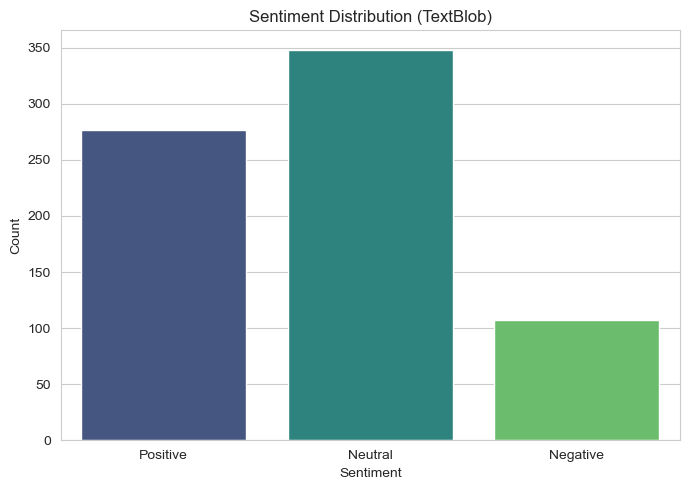

predicted_sentiment
Neutral     348
Positive    277
Negative    107
Name: count, dtype: int64
predicted_sentiment
Neutral     47.5
Positive    37.8
Negative    14.6
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(7, 5))
order = ['Positive', 'Neutral', 'Negative']
sns.countplot(x='predicted_sentiment', data=df, order=order, palette='viridis')
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()

print(df['predicted_sentiment'].value_counts())
print(df['predicted_sentiment'].value_counts(normalize=True).round(3) * 100)

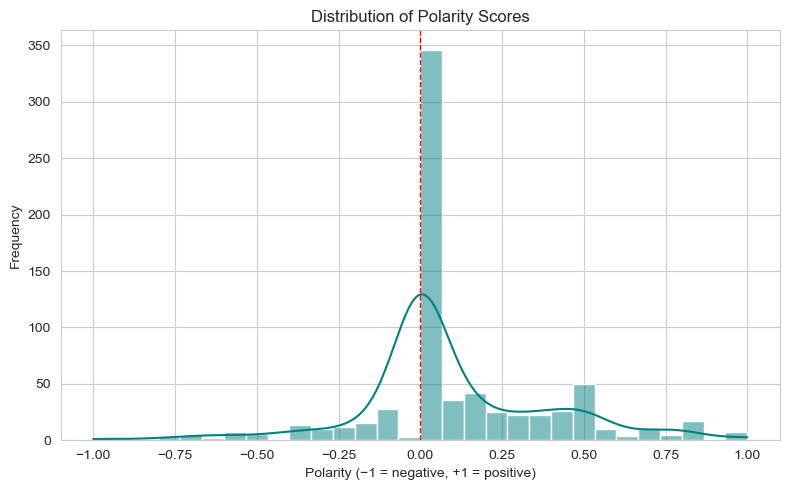

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['polarity'], bins=30, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Distribution of Polarity Scores')
plt.xlabel('Polarity (−1 = negative, +1 = positive)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("polarity_score.png", dpi=150)
plt.show()

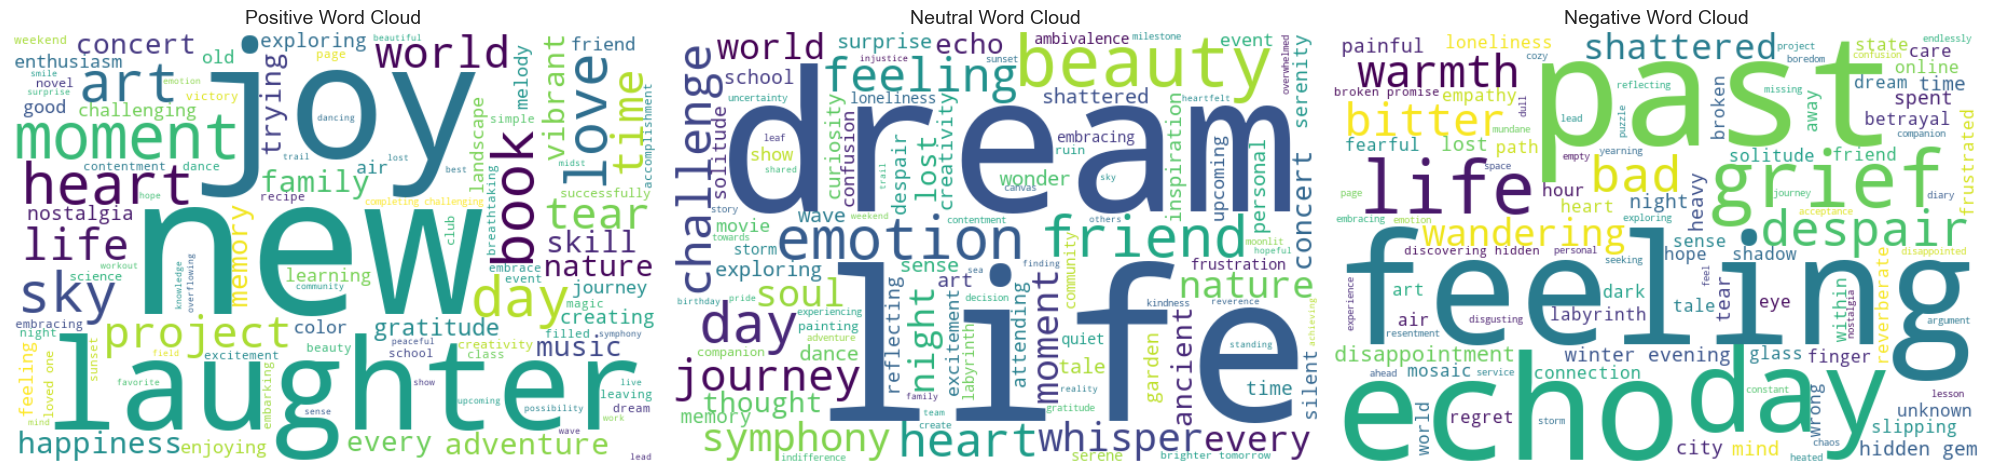

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    text = " ".join(df.loc[df['predicted_sentiment'] == sentiment, 'clean_text'])
    if text.strip():
        wc = WordCloud(width=600, height=400, background_color='white',
                        colormap='viridis', max_words=100).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment} Word Cloud', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig("word_clouds.png", dpi=150)
plt.show()

C:\Users\FBDA22-007\AppData\Local\Temp\ipykernel_23544\1526103616.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='mako')


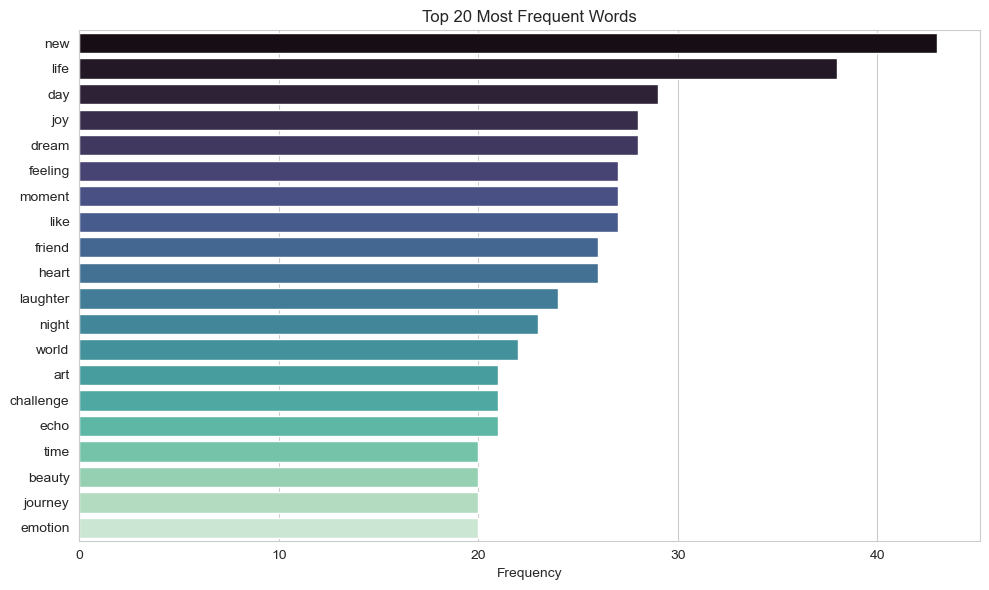

In [14]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='mako')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig("word_frequency.png", dpi=150)
plt.show()

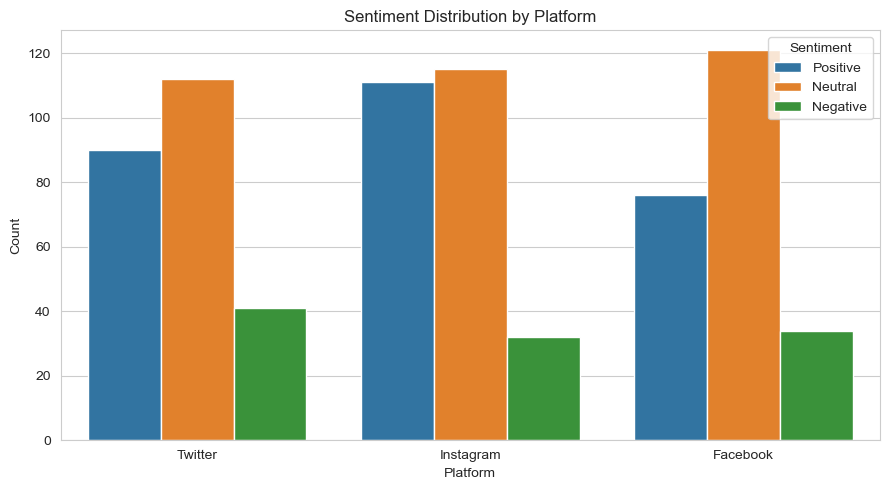

In [15]:
plt.figure(figsize=(9, 5))
sns.countplot(x='Platform', hue='predicted_sentiment', data=df, hue_order=order)
plt.title('Sentiment Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig("platform_vs_sentiment.png", dpi=150)
plt.show()